# Demographic-confounding sensitivity

Each point is one (method, disease). x = AUROC when the healthy controls are sampled uniformly at random (mean of 5 reps); y = AUROC when the healthy controls are matched to the disease cohort's demographic distribution (single deterministic match). Distance from the y=x diagonal quantifies how much demographic matching changed the result.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Config

In [2]:
METHODS = ["Emerson 2017", "Ostmeyer 2019", "V/J-gkmer (LogReg)"]
DISEASES = ["Lupus", "HIV", "Influenza", "Covid19"]

DISEASE_SUBTITLE = {
    "Lupus":     "age",
    "HIV":       "ancestry",
    "Influenza": "age",
    "Covid19":   "age",
}

DISEASE_COLORS = {
    "HIV":       "#028E68",
    "Lupus":     "#CC79A7",
    "Influenza": "#F0E442",
    "Covid19":   "#56B4E9",
    "T1D":       "#E69F00",
    "TB":        "#00669E",
    "RA":        "#D55E00",
}

METHOD_MARKERS = {
    "Emerson 2017":        "o",
    "Ostmeyer 2019":       "s",
    "V/J-gkmer (LogReg)": "D",
}

## Results table

(disease, method) → (random_baseline_AUROC, demographic_adjusted_AUROC)

In [3]:
AUROC = {
    ("Lupus",     "Emerson 2017"):        (0.7115, 0.6192),
    ("Lupus",     "Ostmeyer 2019"):       (0.6000, 0.6457),
    ("Lupus",     "V/J-gkmer (LogReg)"): (0.8776, 0.8711),

    ("HIV",       "Emerson 2017"):        (0.5792, 0.5000),
    ("HIV",       "Ostmeyer 2019"):       (0.7000, 0.6778),
    ("HIV",       "V/J-gkmer (LogReg)"): (0.8224, 0.5716),

    ("Influenza", "Emerson 2017"):        (0.7988, 0.8185),
    ("Influenza", "Ostmeyer 2019"):       (0.5000, 0.6185),
    ("Influenza", "V/J-gkmer (LogReg)"): (0.9642, 0.9306),

    ("Covid19",   "Emerson 2017"):        (0.5000, 0.5000),
    ("Covid19",   "Ostmeyer 2019"):       (0.6000, 0.5991),
    ("Covid19",   "V/J-gkmer (LogReg)"): (0.8093, 0.9009),
}

## Plot helper

In [4]:
def make_figure(out_path=None):
    fig, ax = plt.subplots(figsize=(7.0, 6.5))

    lo, hi = 0.45, 1.0
    ax.plot([lo, hi], [lo, hi], color="0.7", linestyle="--", linewidth=1, zorder=1)
    ax.fill_between([lo, hi], [lo - 0.05, hi - 0.05], [lo + 0.05, hi + 0.05],
                    color="0.85", alpha=0.35, zorder=0,
                    label="_nolegend_")

    for (disease, method), (x, y) in AUROC.items():
        ax.scatter(
            x, y,
            color=DISEASE_COLORS[disease],
            marker=METHOD_MARKERS[method],
            s=110, edgecolor="black", linewidth=0.6, zorder=3,
        )

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_aspect("equal")
    ax.set_xlabel("Random healthy-control AUROC\n(mean of 5 random samples)", fontsize=11)
    ax.set_ylabel("Demographic-matched healthy-control AUROC", fontsize=11)
    # ax.set_title("Sensitivity of disease-classification AUROC to\n"
    #              "healthy-control demographic matching", fontsize=11)
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)

    disease_handles = [
        plt.Line2D([0], [0], marker="o", color="w",
                   markerfacecolor=DISEASE_COLORS[d], markeredgecolor="black",
                   markeredgewidth=0.6, markersize=9,
                   label=f"{d} ({DISEASE_SUBTITLE[d]})")
        for d in DISEASES
    ]
    method_handles = [
        plt.Line2D([0], [0], marker=METHOD_MARKERS[m], color="w",
                   markerfacecolor="0.55", markeredgecolor="black",
                   markeredgewidth=0.6, markersize=9, label=m)
        for m in METHODS
    ]

    leg1 = ax.legend(handles=disease_handles, title="Disease (matched on)",
                     loc="upper left", bbox_to_anchor=(1.01, 1.0),
                     frameon=False, fontsize=11, title_fontsize=11)
    ax.add_artist(leg1)
    ax.legend(handles=method_handles, title="Method",
              loc="upper left", bbox_to_anchor=(0.98, 0.55),
              frameon=False, fontsize=11, title_fontsize=11)

    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=200, bbox_inches="tight")
    return fig

## Render

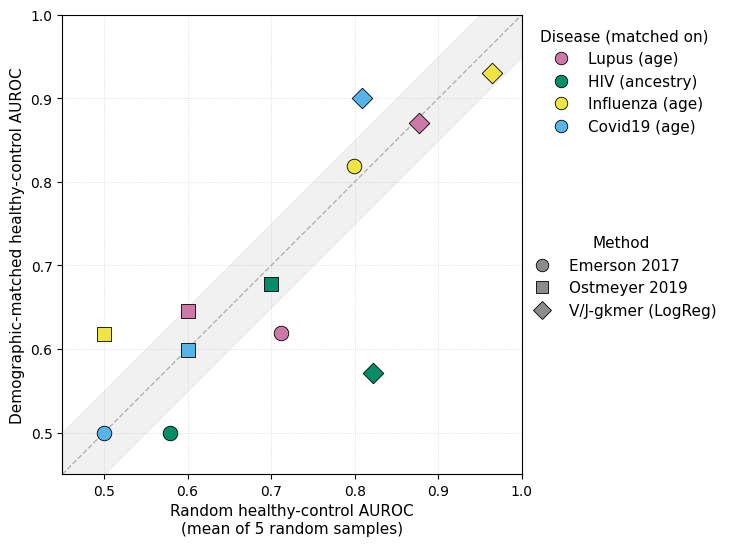

In [5]:
fig = make_figure(out_path="demographic_sensitivity.pdf")
plt.show()